In [74]:
import math
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import os
import time
from tqdm.auto import tqdm

import sys
sys.path.insert(0, "/home/palakons/shapevae")#files are relative to singularity home, coz the server is running singularity from there
from model.ptv3_based_model import PointVAE, VAEConfig


from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from pytorch3d.loss import chamfer_distance
import numpy as np

import wandb




# autoreload py
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:

from experiment_runner import ExperimentConfig, run_training
from shapenet_dataset import ShapeNetDataset
from visualize import visualize_reconstructions, plot_pointclouds

from model.ptv3_based_model import PointVAE, VAEConfig,check_voxel_collisions
from model.losses import repulsion_exp_loss,loss_fn_cd_plus_real_repulsion,loss_fn_cd,loss_fn_cd_plus_repulsion
from model.base_model import PointCloudAE

from shapevae.visualize import visualize_interpolations

In [76]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# precompute with ```python precompute_pointcloud.py --data-dir /ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/ --object-class 03001627 --output-dir ./sampled_poincloud/ --num-points 1024```

dataset = ShapeNetDataset(data_dir='./shapevae/sampled_poincloud_clip/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


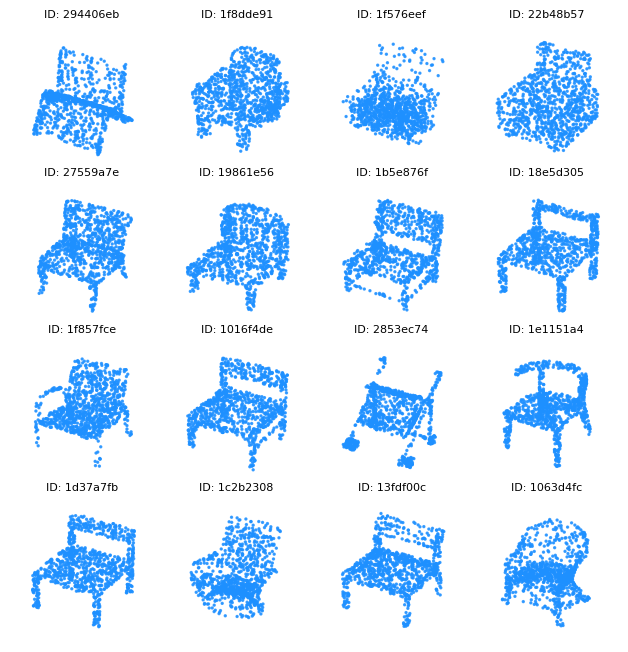

In [77]:

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list)
    break

## Setting up

In [78]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42
run_root="/shapevae_weights"

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)


device: cuda


## Align AE embeddings to CLIP embeddings with a projection head
- Pick one of the trained AEs from logged wandb runs on shared project (alephnir-vistec/shapevae)
- finetune a small projection head to align the AE latent space with CLIP embeddings of rendered views of the shapes.
- make sure record metrics on wandb and the checkpointing on "weigths" dir

In [79]:
class AECLIPProjectionHead(nn.Module):
    def __init__(self, input_dim=1024, output_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [80]:
import os, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
import wandb
wandb.login()
api = wandb.Api()

In [96]:
model_adaptor = AECLIPProjectionHead(input_dim=z_dim, output_dim=512).to(device)
optimizer_adaptor = torch.optim.Adam(model_adaptor.parameters(), lr=lr)
loss_fn_adaptor = nn.MSELoss()

cfg_adaptor = ExperimentConfig(
    name="baseline_adaptor",
    num_epochs=num_epochs,
    seed=seed,
    use_amp=True,
    save_every=10,
    run_root=run_root,)



def train_adaptor(  config,
    point_ae_model,
    adaptor_model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    device,
):
    '''
    gt: batch.clip_latent (B, 512)
    pred: model(batch.points) -> (B, 512)
    '''

    best_val_loss = float('inf')
    point_ae_model.eval()  # freeze point AE during adaptor training

    # outer bar: do not leave previous bars in notebook
    ppbar = tqdm(range(config.num_epochs), desc="Adaptor Training", leave=False, position=0)
    for epoch in ppbar:
        adaptor_model.train()

        train_loss = 0.0
        # inner training bar at position 1 so it replaces/clears correctly
        for batch in train_loader:
            points = batch['points'].to(device)  # (B, N, 3)
            clip_latent = batch['clip_latent'].to(device)  # (B, 512)

            optimizer.zero_grad()
            z = point_ae_model.encoder(points)  # (B, 1024)
            pred_clip_latent = adaptor_model(z)  # (B, 512)
            loss = loss_fn(pred_clip_latent, clip_latent)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * points.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)

        # Validation
        adaptor_model.eval()
        val_loss = 0.0
        # validation bar at same position as training to avoid stacking
        with torch.no_grad():
            for batch in val_loader:
                points = batch['points'].to(device)  # (B, N, 3)
                clip_latent = batch['clip_latent'].to(device)  # (B, 512)

                z = point_ae_model.encoder(points)  # (B, 1024)
                pred_clip_latent = adaptor_model(z)  # (B, 512)
                loss = loss_fn(pred_clip_latent, clip_latent)
                val_loss += loss.item() * points.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)



        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_path = os.path.join(config.run_root, "best_adaptor.pt")
            torch.save(adaptor_model.state_dict(), best_path)
    

        ppbar.set_description(f"Train:{avg_train_loss:.4f}, Val:{avg_val_loss:.4f}")

    return config.run_root, {'best_val_loss': best_val_loss}


In [ ]:


api = wandb.Api()
runs = api.runs("alephnir-vistec/shapevae")
# runs = api.runs("palakon-k/shapevae")

print(f"Found {len(runs)} runs in wandb project.")

for run in runs:
    #check for run_dir in run summary
    # print(run.name, run.id,run.summary['epoch'] )
    if "run_dir" in run.summary and run.summary['epoch'] == 100 and run.id== "giplbpyz": # only check checkpoints for runs that completed full training and are ptv3-based
        print("  run_dir:", run.summary["run_dir"].replace("/ist-nas/ist-share/vision/pratchp", ""))
        
        best_checkpoint_path = os.path.join(run.summary["run_dir"].replace("/ist-nas/ist-share/vision/pratchp", ""), "checkpoints/best.pt")

        if os.path.exists(best_checkpoint_path):
            # print("    Found checkpoint:", best_checkpoint_path)
            checkpoint = torch.load(best_checkpoint_path, map_location=device)
            # print(f"keys in checkpoint: {checkpoint.keys()}") #['epoch', 'best_val', 'model_state_dict', 'optimizer_state_dict', 'config']
            model_state_dict = checkpoint["model_state_dict"]
            if "ptv3" in run.name:
                cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=num_points, variational=("vae" in run.name)   , grid_size=.01)
                point_ae_model = PointVAE(cfg=cfg).to(device)
            elif "baseline" in run.name:
                point_ae_model = PointCloudAE(z_dim=z_dim, num_points=num_points)
            else:
                print("    Unrecognized model type in run name. Skipping visualization.")
                continue

            point_ae_model.load_state_dict(model_state_dict)
            point_ae_model.to(device)
            point_ae_model.eval()
            # Visualize interpolations for this model
            # visualize_interpolations(point_ae_model, val_loader, device=device,title=run.name)
            
            
            print(f"Training adaptor for run: {run.name}")
            run_dir_adaptor, summary_adaptor = train_adaptor(
                config=cfg_adaptor,
                point_ae_model=point_ae_model,  # use the same model as point AE since we're only training a small projection head on top
                adaptor_model=model_adaptor,
                optimizer=optimizer_adaptor,
                loss_fn=loss_fn_adaptor,
                train_loader=train_loader,
                val_loader=val_loader,
                device=device,
            )
        else:
            print("    Checkpoint not found. Skipping visualization.")
    run_id = run.id
    break

Found 12 runs in wandb project.
  run_dir: /shapevae_weights/20260427-115805_palakons_baseline_cd
Training adaptor for run: baseline_cd


Adaptor Training:   0%|          | 0/100 [00:00<?, ?it/s]

Keyword: tall
  Min sim: 0.2233 at index 6


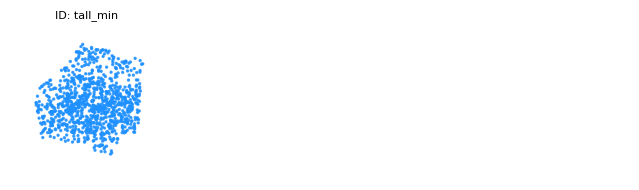

  Max sim: 0.2383 at index 5


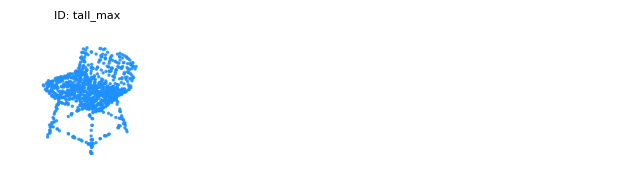

Keyword: short
  Min sim: 0.2290 at index 11


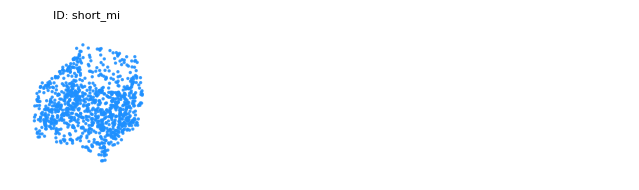

  Max sim: 0.2443 at index 5


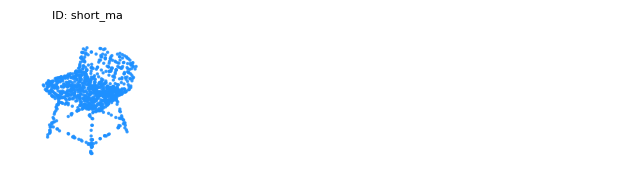

Keyword: legged
  Min sim: 0.2137 at index 11


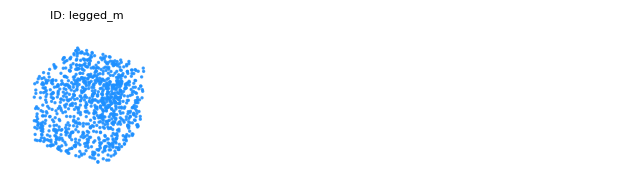

  Max sim: 0.2498 at index 13


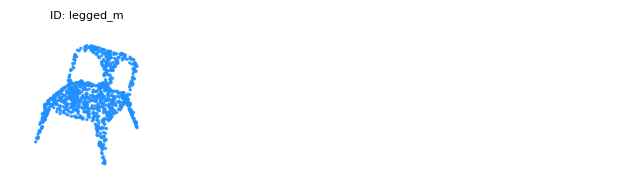

Keyword: swivel
  Min sim: 0.2361 at index 6


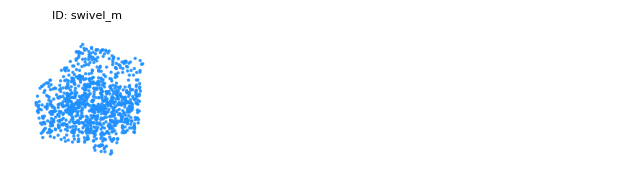

  Max sim: 0.2578 at index 8


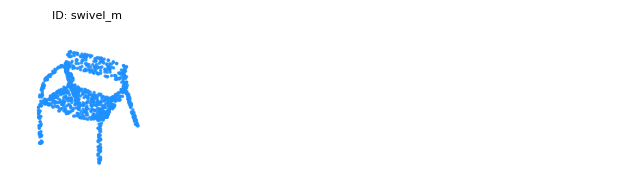

Keyword: round
  Min sim: 0.2301 at index 11


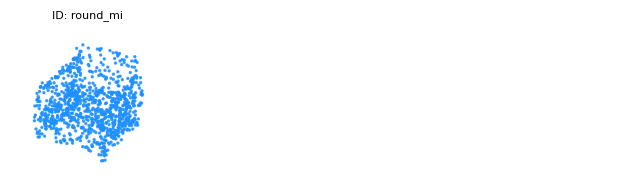

  Max sim: 0.2432 at index 14


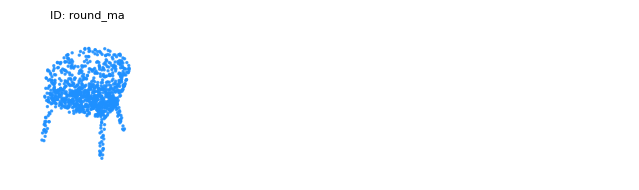

Keyword: flat
  Min sim: 0.2231 at index 11


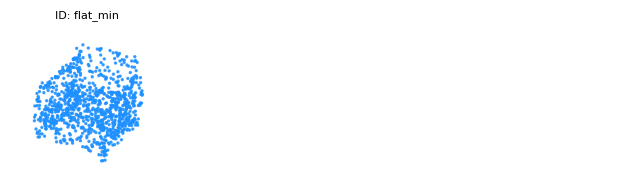

  Max sim: 0.2454 at index 7


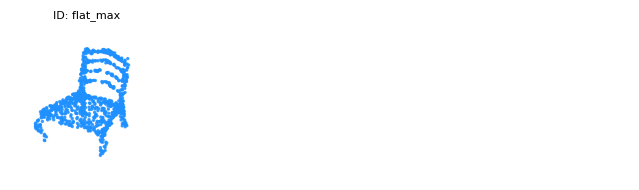

Keyword: pointy
  Min sim: 0.2152 at index 12


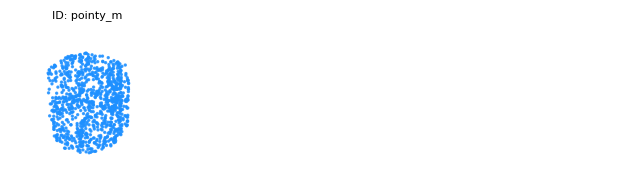

  Max sim: 0.2417 at index 9


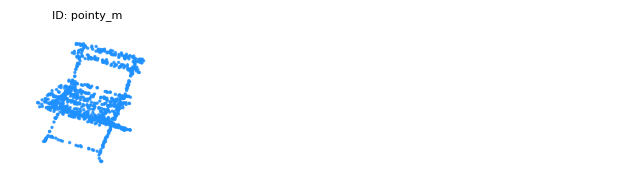

In [ ]:
import clip

model_name = "ViT-B/32"
clip_model, preprocess = clip.load(model_name, device=device, jit=False)
clip_model.eval()
clip_model.to(device)

model_adaptor.eval()

#coome up with chaor attribute
keywords = ["tall", "short", "legged","swivel","round","flat","pointy"]


kw_tokens = clip.tokenize(keywords).to(device)                   # (K,)
kw_clip_latents = clip_model.encode_text(kw_tokens).detach()    # (K,512)
kw_norm = F.normalize(kw_clip_latents, dim=1).float()                    # (K,512)

overall_min_sim = [float('inf')] * len(keywords)
overall_max_sim = [float('-inf')] * len(keywords)
pc_max = [None] * len(keywords)
pc_min = [None] * len(keywords)

for batch in val_loader:
    points = batch['points'].to(device)  # (B, N, 3)

    z = point_ae_model.encoder(points)  # (B, 1024)
    pred_clip_latent = model_adaptor(z)  # (B, 512)
    

    pred_norm = F.normalize(pred_clip_latent, dim=1).float()     # (B,512)
    sims = pred_norm @ kw_norm.t()                      # (B, K)

    # for keyword index k, column = sims[:, k]
    for k_idx, keyword in enumerate(keywords):
        col = sims[:, k_idx]                           # (B,)
        batch_min_sim, batch_min_idx = torch.min(col, dim=0)
        batch_max_sim, batch_max_idx = torch.max(col, dim=0)
        if batch_min_sim < overall_min_sim[k_idx]:
            overall_min_sim[k_idx] = batch_min_sim.item()
            pc_min[k_idx] = points[batch_min_idx].cpu().numpy()  # (N, 3)
        if batch_max_sim > overall_max_sim[k_idx]:
            overall_max_sim[k_idx] = batch_max_sim.item()
            pc_max[k_idx] = points[batch_max_idx].cpu().numpy()  # (N, 3)

# visualize the point clouds with lowest and highest similarity for each keyword
for k_idx, keyword in enumerate(keywords):
    print(f"Keyword: {keyword}")
    if pc_min[k_idx] is not None:
        print(f"  Min sim: {overall_min_sim[k_idx]:.4f}")
        plot_pointclouds([(f"v{keyword}", pc_min[k_idx])])
    else:
        print("    Checkpoint not found. Skipping visualization.")
    
    if pc_max[k_idx] is not None:
        print(f"  Max sim: {overall_max_sim[k_idx]:.4f}")
        plot_pointclouds([(f"^{keyword}", pc_max[k_idx])])